Gen 1 | Curr: 26.6175 | Best: 26.6175
Gen 2 | Curr: 25.3847 | Best: 25.3847
Gen 3 | Curr: 25.3847 | Best: 25.3847
Gen 4 | Curr: 24.8029 | Best: 24.8029
Gen 5 | Curr: 24.8029 | Best: 24.8029
Gen 6 | Curr: 24.8029 | Best: 24.8029
Gen 7 | Curr: 24.3119 | Best: 24.3119
Gen 8 | Curr: 24.3119 | Best: 24.3119
Gen 9 | Curr: 22.8390 | Best: 22.8390
Gen 10 | Curr: 22.8390 | Best: 22.8390
Gen 11 | Curr: 22.8390 | Best: 22.8390
Gen 12 | Curr: 21.9649 | Best: 21.9649
Gen 13 | Curr: 21.9649 | Best: 21.9649
Gen 14 | Curr: 21.9649 | Best: 21.9649
Gen 15 | Curr: 21.9649 | Best: 21.9649
Gen 16 | Curr: 21.9649 | Best: 21.9649
Gen 17 | Curr: 21.9649 | Best: 21.9649
Gen 18 | Curr: 21.9649 | Best: 21.9649
Gen 19 | Curr: 21.8584 | Best: 21.8584
Gen 20 | Curr: 21.8584 | Best: 21.8584
Gen 21 | Curr: 21.6955 | Best: 21.6955
Gen 22 | Curr: 21.1583 | Best: 21.1583
Gen 23 | Curr: 21.1583 | Best: 21.1583
Gen 24 | Curr: 21.1583 | Best: 21.1583
Gen 25 | Curr: 21.1583 | Best: 21.1583
Gen 26 | Curr: 21.1583 | Best: 21.

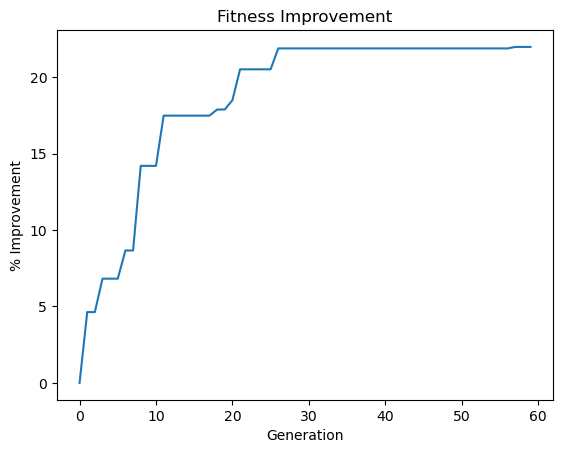

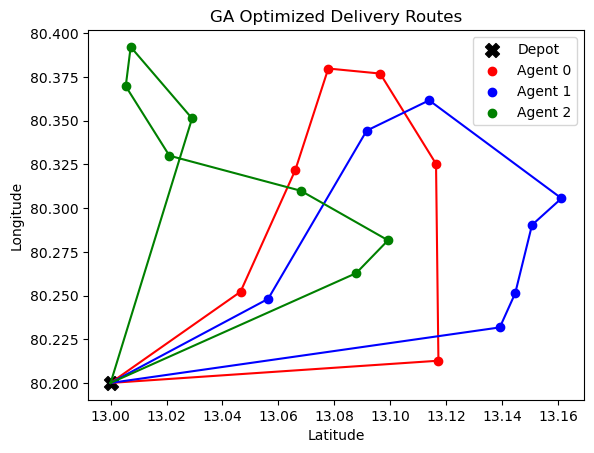

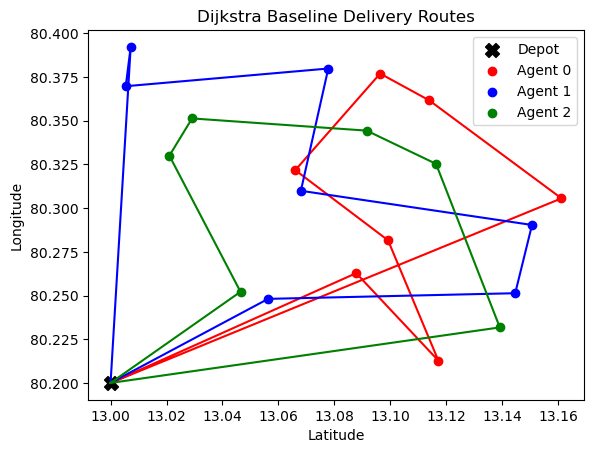

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

# parameters
nAgents = 3
nDeliveries = 20

POP_SIZE = 40
GENERATIONS = 60
ELITE_SIZE = 2

W_MAX = 3.0
rho = 0.7

# balanced wweigts
w_dist = 3
w_var = 6
w_max = 15
w_total = 5   
w_fair = 10

# depot
depot = np.array([13.0, 80.2])

locations = np.array([
    [13.0 + random.random()*0.2, 80.2 + random.random()*0.2]
    for _ in range(nDeliveries)
])

def route_length(points):
    if len(points) == 0:
        return 0
    dist = np.linalg.norm(depot - points[0])
    for i in range(len(points)-1):
        dist += np.linalg.norm(points[i] - points[i+1])
    dist += np.linalg.norm(points[-1] - depot)
    return dist


def two_opt(points):
    if len(points) < 3:
        return points
    best = points.copy()
    improved = True
    while improved:
        improved = False
        for i in range(1, len(points)-1):
            for j in range(i+1, len(points)):
                new = best[:i] + best[i:j][::-1] + best[j:]
                if route_length(new) < route_length(best):
                    best = new
                    improved = True
    return best

# initial pop
def init_population():
    return [[random.randint(0, nAgents-1) for _ in range(nDeliveries)]
            for _ in range(POP_SIZE)]

# workload
def compute_workload(chromo):
    agent_points = [[] for _ in range(nAgents)]

    for i in range(len(chromo)):
        agent_points[chromo[i]].append(locations[i])

    W = np.zeros(nAgents)
    route_distances = np.zeros(nAgents)

    for i in range(nAgents):
        pts = two_opt(agent_points[i])
        dist = route_length(pts)

        route_distances[i] = dist
        W[i] = dist

    return W, route_distances, agent_points

# fariness
def fairness(W):
    return (np.max(W) - np.min(W)) / (np.sum(W) + 1e-6)

# fitness
def compute_fitness(W, route_distances, agent_points):

    total_distance = np.sum(route_distances)
    var = np.var(W)
    max_load = np.max(W)
    total_load = np.sum(W)


    overload_penalty = sum([20*(w-W_MAX)**2 for w in W if w > W_MAX])
    stops_penalty = np.var([len(agent_points[i]) for i in range(nAgents)])

    fitness = (
        w_dist * total_distance
        + w_var * var
        + w_max * max_load
        + w_total * total_load   
        + w_fair * fairness(W)
        + overload_penalty
        + 5 * stops_penalty
    )

    return fitness


def tournament_selection(pop, fitnesses):
    selected = random.sample(list(zip(pop, fitnesses)), 3)
    selected.sort(key=lambda x: x[1])
    return selected[0][0]

def crossover(p1, p2):
    point1 = 5
    point2 = 10

    child = p1[:point1] + p2[point1:point2] + p1[point2:]
    return child

def mutate(chromo):
    for _ in range(3):
        i = random.randint(0, len(chromo)-1)
        chromo[i] = random.randint(0, nAgents-1)
        
    return chromo


population = init_population()

best_solution = None
best_fitness = float('inf')
fitness_history = []

for gen in range(GENERATIONS):

    fitnesses = []
    workloads = []

    for chromo in population:
        W, route_distances, agent_points = compute_workload(chromo)
        fit = compute_fitness(W, route_distances, agent_points)

        fitnesses.append(fit)
        workloads.append(W)

        if fit < best_fitness:
            best_fitness = fit
            best_solution = chromo.copy()

    current_best = min(fitnesses)
    fitness_history.append(current_best)

    # diversity
    if gen % 5 == 0:
        for _ in range(5):
            population[random.randint(0, POP_SIZE-1)] = [
                random.randint(0, nAgents-1) for _ in range(nDeliveries)
            ]

    sorted_pop = [x for _, x in sorted(zip(fitnesses, population))]
    new_population = sorted_pop[:ELITE_SIZE]

    while len(new_population) < POP_SIZE:
        p1 = tournament_selection(population, fitnesses)
        p2 = tournament_selection(population, fitnesses)

        child = crossover(p1, p2)
        child = mutate(child)

        new_population.append(child)

    population = new_population

    print(f"Gen {gen+1} | Curr: {current_best:.4f} | Best: {best_fitness:.4f}")


W, route_distances, _ = compute_workload(best_solution)

# dijikstras
def dijkstra_baseline():
    agent_points = [[] for _ in range(nAgents)]
    for i in range(nDeliveries):
        agent_points[i % nAgents].append(locations[i])
    return np.array([route_length(p) for p in agent_points])

dij_W = dijkstra_baseline()

# res
print("\nfinal comparison")

print("\ndistance")
print(f"Dijkstra: {np.sum(dij_W):.2f}")
print(f"GA: {np.sum(route_distances):.2f}")

print("\nMax Load")
print(f"Dijkstra: {np.max(dij_W):.2f}")
print(f"GA: {np.max(W):.2f}")

print("\nvariance")
print(f"Dijkstra: {np.var(dij_W):.4f}")
print(f"GA: {np.var(W):.4f}")

print("\nFairness")
print(f"Dijkstra: {fairness(dij_W):.4f}")
print(f"GA: {fairness(W):.4f}")

# ---------------- PLOT ----------------
initial = fitness_history[0]
percent_improve = [(initial - f)/initial * 100 for f in fitness_history]
plt.plot(percent_improve)
plt.title("Fitness Improvement")
plt.xlabel("Generation")
plt.ylabel("% Improvement")
plt.show()


# viz
colors = ['red', 'blue', 'green', 'purple', 'orange']

# plot depot
plt.scatter(depot[0], depot[1], c='black', marker='X', s=100, label='Depot')

# plot deliveries per agent
agent_points = [[] for _ in range(nAgents)]
for i in range(nDeliveries):
    agent_points[best_solution[i]].append(locations[i])

for i in range(nAgents):
    pts = np.array(agent_points[i])
    if len(pts) == 0:
        continue
    
    # plot points
    plt.scatter(pts[:,0], pts[:,1], color=colors[i], label=f'Agent {i}')
    
    # plot route
    pts = two_opt(list(pts))
    route = [depot] + pts + [depot]
    route = np.array(route)
    
    plt.plot(route[:,0], route[:,1], color=colors[i])

plt.title("GA Optimized Delivery Routes")
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.legend()
plt.show()
# ---------------- DIJKSTRA VIS ----------------

# plot depot
plt.scatter(depot[0], depot[1], c='black', marker='X', s=100, label='Depot')

# assign points like your baseline
agent_points = [[] for _ in range(nAgents)]
for i in range(nDeliveries):
    agent_points[i % nAgents].append(locations[i])

# plot per agent
for i in range(nAgents):
    pts = np.array(agent_points[i])
    if len(pts) == 0:
        continue
    
    # plot points
    plt.scatter(pts[:,0], pts[:,1], color=colors[i], label=f'Agent {i}')
    
    # plot route (same as GA)
    pts = two_opt(list(pts))
    route = [depot] + pts + [depot]
    route = np.array(route)
    
    plt.plot(route[:,0], route[:,1], color=colors[i])

plt.title("Dijkstra Baseline Delivery Routes")
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.legend()
plt.show()